In [1]:
"""
=============================================================================
ANÁLISIS DE EXOPLANETAS KEPLER CON MACHINE LEARNING
Servicio Social: Clasificación usando Árboles de Decisión y Random Forest
Autor: Jesús Alberto Cerón Hernández
Fecha: 2025
=============================================================================
"""

# 0. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
print("=" * 80)
print("INICIANDO ANÁLISIS DE EXOPLANETAS KEPLER")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos principales
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# Configuración
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10
print("Librerías cargadas exitosamente.")


INICIANDO ANÁLISIS DE EXOPLANETAS KEPLER
Librerías cargadas exitosamente.


In [2]:
# =============================================================================
# 1. FUNCIONES AUXILIARES
# =============================================================================

def print_section(title):
    """Imprime un separador de sección formateado"""
    print(f"\n{'='*80}")
    print(f"{title}")
    print('='*80)


def analyze_class_distribution(y, title="Distribución de Clases"):
    """Analiza y visualiza la distribución de clases"""
    class_counts = y.value_counts()
    class_percentages = y.value_counts(normalize=True) * 100
    
    print(f"\n{title}:")
    print("-" * 50)
    for class_name, count, percentage in zip(class_counts.index, class_counts.values, class_percentages.values):
        label = {0: 'FALSE POSITIVE', 1: 'CONFIRMED', 2: 'CANDIDATE'}.get(class_name, str(class_name))
        print(f"{label}: {count:,} ({percentage:.2f}%)")
    
    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['#E74C3C', '#1ABC9C', '#34495E']
    bars = ax1.bar(range(len(class_counts)), class_counts.values, color=colors[:len(class_counts)])
    ax1.set_xticks(range(len(class_counts)))
    ax1.set_xticklabels(['FALSE POSITIVE', 'CONFIRMED', 'CANDIDATE'][:len(class_counts)])
    ax1.set_ylabel('Cantidad')
    ax1.set_title('Distribución de Clases - Conteo')
    ax1.grid(axis='y', alpha=0.3)

    # Agregar los números encima de cada barra
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(class_counts.values)*0.01,
                 f'{int(height):,}', ha='center', va='bottom')
    
    ax2.pie(class_counts.values, labels=['FALSE POSITIVE', 'CONFIRMED', 'CANDIDATE'][:len(class_counts)],
            autopct='%1.1f%%', colors=colors[:len(class_counts)], startangle=90)
    ax2.set_title('Distribución de Clases - Porcentaje')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def plot_learning_curves(model, X, y, cv=5, title="Curvas de Aprendizaje"):
    """Genera curvas de aprendizaje para evaluar overfitting/underfitting"""
    train_sizes = np.linspace(0.1, 1.0, 20)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes,
        scoring='accuracy', shuffle=True, random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(train_sizes, train_mean, 'o-', color='#2E86AB', label='Score de Entrenamiento', linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2E86AB')
    
    plt.plot(train_sizes, val_mean, 'o-', color='#A23B72', label='Score de Validación', linewidth=2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#A23B72')
    
    gap = train_mean[-1] - val_mean[-1]
    plt.text(0.7, 0.2, f'Gap final: {gap:.3f}', transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylim(0.5, 1.02)
    plt.tight_layout()
    plt.show()
    
    # Diagnóstico
    if gap > 0.05:
        print(f"OVERFITTING detectado (gap = {gap:.3f})")
    elif val_mean[-1] < 0.7:
        print(f"UNDERFITTING detectado (score validación = {val_mean[-1]:.3f})")
    else:
        print(f"Modelo bien ajustado (gap = {gap:.3f})")

def feature_importance_analysis(model, feature_names, top_n=15):
    """Analiza y visualiza la importancia de características"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]
        
        plt.figure(figsize=(12, 6))
        plt.title(f'Top {top_n} Características Más Importantes')
        plt.bar(range(top_n), importances[indices], color='steelblue')
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.ylabel('Importancia')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return pd.DataFrame({
            'Feature': [feature_names[i] for i in indices],
            'Importance': importances[indices]
        })


In [3]:
# =============================================================================
# 2. CARGA Y EXPLORACIÓN DE DATOS
# =============================================================================
print_section("CARGA Y EXPLORACIÓN DE DATOS")

try:
    df = pd.read_csv("cumulative.csv")
    print(f"Archivo CSV cargado exitosamente.")
    print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print("Error: El archivo 'cumulative.csv' no se encontró.")
    exit()


CARGA Y EXPLORACIÓN DE DATOS
Archivo CSV cargado exitosamente.
Dimensiones del dataset: 9,564 filas × 50 columnas
Memoria utilizada: 5.84 MB



LIMPIEZA Y PREPARACIÓN DE DATOS
Eliminadas 13 columnas de metadatos
Eliminadas 2 columnas con >50% valores nulos
Dataset final: 34 características, 9,564 observaciones

Distribución de Clases:
--------------------------------------------------
FALSE POSITIVE: 5,023 (52.52%)
CONFIRMED: 2,293 (23.98%)
CANDIDATE: 2,248 (23.50%)


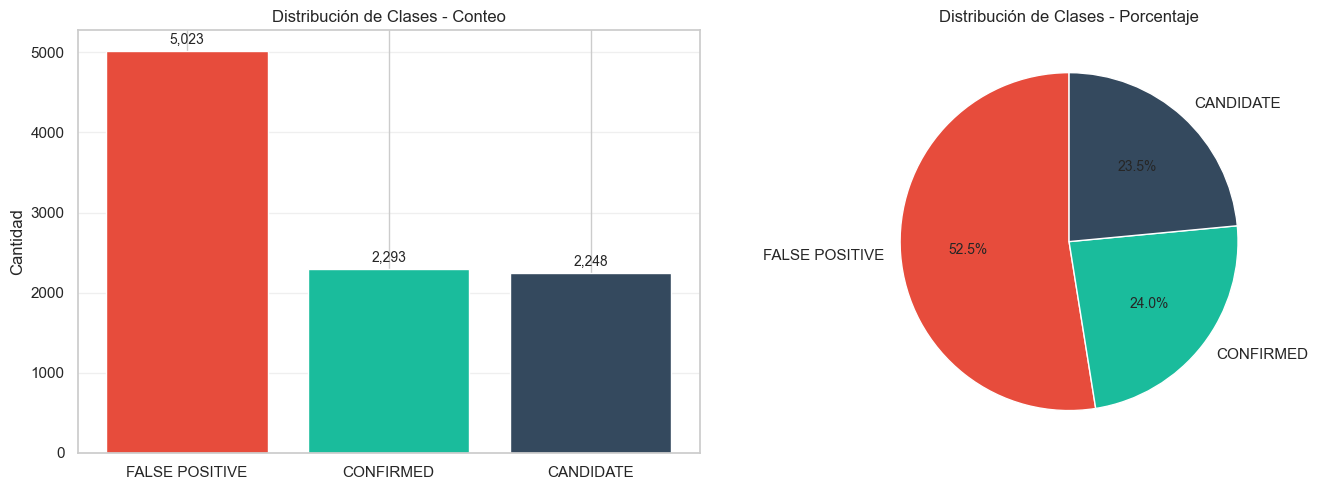

División: 6,694 entrenamiento, 2,870 prueba


In [4]:
# =============================================================================
# 3. LIMPIEZA Y PREPARACIÓN DE DATOS
# =============================================================================
print_section("LIMPIEZA Y PREPARACIÓN DE DATOS")

# Columnas a eliminar (metadatos e identificadores)
cols_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition',
    'koi_tce_delivname', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 
    'koi_fpflag_co', 'koi_fpflag_ec', 'koi_model_snr', 'koi_tce_plnt_num'
]

df_cleaned = df.copy()
existing_cols = [col for col in cols_to_drop if col in df_cleaned.columns]
df_cleaned = df_cleaned.drop(columns=existing_cols)
df_cleaned = df_cleaned.dropna(subset=['koi_disposition'])
print(f"Eliminadas {len(existing_cols)} columnas de metadatos")

# Manejo de valores infinitos
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

# Mapeo de la variable objetivo
disposition_mapping = {'CONFIRMED': 1, 'FALSE POSITIVE': 0, 'CANDIDATE': 2}
df_cleaned['koi_disposition'] = df_cleaned['koi_disposition'].map(disposition_mapping)
target_names = ['FALSE POSITIVE', 'CONFIRMED', 'CANDIDATE']

# Eliminar columnas con muchos valores faltantes
missing_fractions = df_cleaned.isnull().mean()
cols_to_drop_missing = missing_fractions[missing_fractions > 0.5].index
df_cleaned = df_cleaned.drop(columns=cols_to_drop_missing)
print(f"Eliminadas {len(cols_to_drop_missing)} columnas con >50% valores nulos")

# Preparación final
X = df_cleaned.drop('koi_disposition', axis=1).select_dtypes(include=np.number)
y = df_cleaned['koi_disposition']
feature_names = X.columns.tolist()

print(f"Dataset final: {X.shape[1]} características, {X.shape[0]:,} observaciones")

# Análisis de distribución de clases
class_distribution = analyze_class_distribution(y)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"División: {X_train.shape[0]:,} entrenamiento, {X_test.shape[0]:,} prueba")


PIPELINE DE PREPROCESAMIENTO OPTIMIZADO
Análisis del dataset:
  Muestras: 6,694
  Características: 34
  Clases: 3
  Relación muestras/características: 196.9
  Dataset balanceado → usando 70% de características
  Problema multiclase → incrementando a 27
  RESULTADO: 27 características seleccionadas

Pipeline aplicado exitosamente:
  Características originales: 34
  Características seleccionadas: 27
  Reducción: 20.6%

Top 15 características más importantes:
          Feature  Selection_Score
         koi_prad           0.1702
koi_duration_err1           0.1654
koi_duration_err2           0.1616
    koi_prad_err1           0.1499
   koi_steff_err1           0.1478
    koi_prad_err2           0.1440
   koi_steff_err2           0.1354
 koi_time0bk_err2           0.1277
 koi_time0bk_err1           0.1247
       koi_period           0.1235
  koi_period_err1           0.1231
  koi_period_err2           0.1230
        koi_depth           0.1093
    koi_srad_err1           0.1027
   koi_slogg_

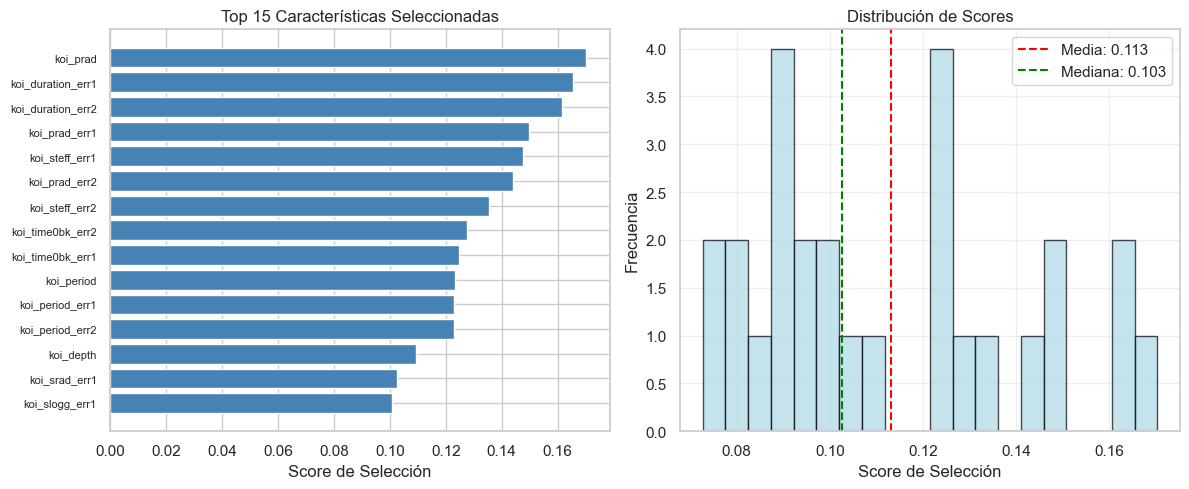

In [5]:
# =============================================================================
# 4. PIPELINE DE PREPROCESAMIENTO OPTIMIZADO
# =============================================================================
print_section("PIPELINE DE PREPROCESAMIENTO OPTIMIZADO")

def determine_optimal_k(X, y):
    """Determina el número óptimo de características basado en el dataset"""
    n_samples, n_features = X.shape
    n_classes = len(np.unique(y))
    samples_per_feature = n_samples / n_features
    
    print(f"Análisis del dataset:")
    print(f"  Muestras: {n_samples:,}")
    print(f"  Características: {n_features}")
    print(f"  Clases: {n_classes}")
    print(f"  Relación muestras/características: {samples_per_feature:.1f}")
    
    # Lógica adaptativa
    if samples_per_feature > 100:  # Dataset muy balanceado
        k_optimal = min(int(0.7 * n_features), 80)
        print(f"  Dataset balanceado → usando 70% de características")
    elif samples_per_feature > 50:  # Dataset balanceado
        k_optimal = min(int(0.5 * n_features), 60)
        print(f"  Dataset moderadamente balanceado → usando 50% de características")
    elif samples_per_feature > 20:  # Dataset moderado
        k_optimal = min(int(0.4 * n_features), 40)
        print(f"  Dataset moderado → usando 40% de características")
    else:  # Dataset con muchas características
        k_optimal = min(int(0.3 * n_features), 30)
        print(f"  Muchas características → usando 30% de características")
    
    # Ajuste para problemas multiclase
    if n_classes > 2:
        k_optimal = int(k_optimal * 1.2)
        print(f"  Problema multiclase → incrementando a {k_optimal}")
    
    # Límites de seguridad
    k_optimal = max(15, min(k_optimal, n_features, 100))
    
    print(f"  RESULTADO: {k_optimal} características seleccionadas")
    return k_optimal

# Determinar k óptimo
k_features = determine_optimal_k(X_train, y_train)

# Crear pipeline optimizado
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(mutual_info_classif, k=k_features)),
    ('scaler', StandardScaler())
])

# Aplicar preprocessing
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Obtener características seleccionadas
selected_mask = preprocessing_pipeline.named_steps['selector'].get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]

print(f"\nPipeline aplicado exitosamente:")
print(f"  Características originales: {len(feature_names)}")
print(f"  Características seleccionadas: {len(selected_features)}")
print(f"  Reducción: {((len(feature_names) - len(selected_features)) / len(feature_names) * 100):.1f}%")

# Análisis de características seleccionadas
selector_scores = preprocessing_pipeline.named_steps['selector'].scores_[selected_mask]
top_features_df = pd.DataFrame({
    'Feature': selected_features,
    'Selection_Score': selector_scores
}).sort_values('Selection_Score', ascending=False)

print(f"\nTop 15 características más importantes:")
print(top_features_df.head(15).to_string(index=False, float_format='%.4f'))

# Estadísticas de los scores
print(f"\nEstadísticas de scores de selección:")
print(f"  Media: {selector_scores.mean():.4f}")
print(f"  Mediana: {np.median(selector_scores):.4f}")
print(f"  Desviación estándar: {selector_scores.std():.4f}")
print(f"  Rango: {selector_scores.min():.4f} - {selector_scores.max():.4f}")

# Visualización de distribución de scores (opcional)
if len(selected_features) > 10:
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Top características
    plt.subplot(1, 2, 1)
    top_15_scores = selector_scores[np.argsort(selector_scores)[::-1][:15]]
    top_15_names = [selected_features[i] for i in np.argsort(selector_scores)[::-1][:15]]
    
    plt.barh(range(len(top_15_names)), top_15_scores, color='steelblue')
    plt.yticks(range(len(top_15_names)), top_15_names, fontsize=8)
    plt.xlabel('Score de Selección')
    plt.title('Top 15 Características Seleccionadas')
    plt.gca().invert_yaxis()
    
    # Subplot 2: Distribución de scores
    plt.subplot(1, 2, 2)
    plt.hist(selector_scores, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
    plt.axvline(selector_scores.mean(), color='red', linestyle='--', 
                label=f'Media: {selector_scores.mean():.3f}')
    plt.axvline(np.median(selector_scores), color='green', linestyle='--', 
                label=f'Mediana: {np.median(selector_scores):.3f}')
    plt.xlabel('Score de Selección')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [6]:
# =============================================================================
# 5. DEFINICIÓN DE MODELOS
# =============================================================================
print_section("DEFINICIÓN DE MODELOS")

models = {
    "Árbol de Decisión (Normal)": DecisionTreeClassifier(random_state=42),
    "Árbol de Decisión (Regularizado)": DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=30, 
        min_samples_leaf=15,
        random_state=42
    ),
    "Random Forest (Normal)": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (Regularizado)": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        max_samples=0.8,
        random_state=42,
        n_jobs=-1
    )
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Modelos definidos: {len(models)}")



DEFINICIÓN DE MODELOS
Modelos definidos: 4


In [7]:
# =============================================================================
# 6. EVALUACIÓN DE MODELOS
# =============================================================================
print_section("EVALUACIÓN COMPARATIVA")

results = []
detailed_results = {}

for name, model in models.items():
    print(f"\nEvaluando: {name}")
    
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train_processed, y_train, 
                                cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    
    # Entrenamiento y evaluación
    model.fit(X_train_processed, y_train)
    train_score = model.score(X_train_processed, y_train)
    test_score = model.score(X_test_processed, y_test)
    gap = train_score - test_score
    
    # Métricas adicionales
    y_pred = model.predict(X_test_processed)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append({
        'Modelo': name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Train Accuracy': train_score,
        'Test Accuracy': test_score,
        'Overfitting Gap': gap,
        'F1-Score': f1_weighted,
        'Kappa': kappa,
        'MCC': mcc
    })
    
    detailed_results[name] = {'model': model, 'y_pred': y_pred, 'cv_scores': cv_scores}
    
    print(f"  CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test: {test_score:.4f}, Gap: {gap:.4f}")

results_df = pd.DataFrame(results)
print("\nTABLA COMPARATIVA DE RENDIMIENTO")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))


EVALUACIÓN COMPARATIVA

Evaluando: Árbol de Decisión (Normal)
  CV: 0.6672 ± 0.0074
  Test: 0.6652, Gap: 0.3348

Evaluando: Árbol de Decisión (Regularizado)
  CV: 0.7133 ± 0.0069
  Test: 0.7132, Gap: 0.0691

Evaluando: Random Forest (Normal)
  CV: 0.7531 ± 0.0060
  Test: 0.7564, Gap: 0.2436

Evaluando: Random Forest (Regularizado)
  CV: 0.7493 ± 0.0032
  Test: 0.7512, Gap: 0.0665

TABLA COMPARATIVA DE RENDIMIENTO
                          Modelo  CV Accuracy  CV Std  Train Accuracy  Test Accuracy  Overfitting Gap  F1-Score  Kappa    MCC
      Árbol de Decisión (Normal)       0.6672  0.0074          1.0000         0.6652           0.3348    0.6677 0.4526 0.4529
Árbol de Decisión (Regularizado)       0.7133  0.0069          0.7823         0.7132           0.0691    0.7112 0.5273 0.5275
          Random Forest (Normal)       0.7531  0.0060          1.0000         0.7564           0.2436    0.7443 0.5893 0.5937
    Random Forest (Regularizado)       0.7493  0.0032          0.8177         


ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS

Analizando importancia para: Random Forest (Normal)


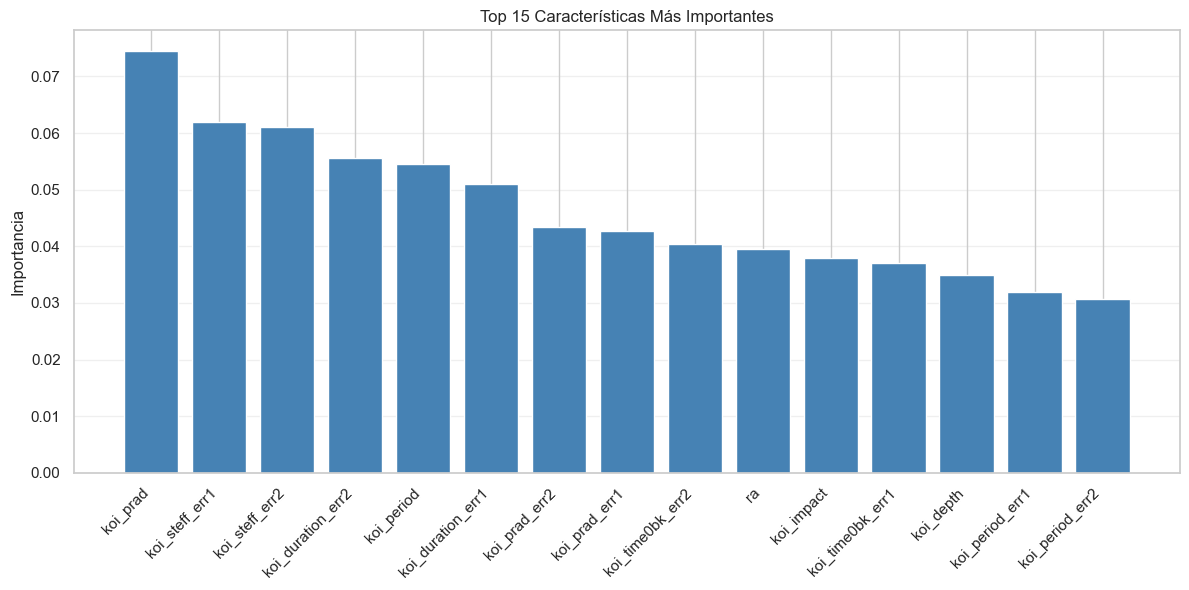


Top 10 características más importantes:
          Feature  Importance
         koi_prad      0.0744
   koi_steff_err1      0.0619
   koi_steff_err2      0.0610
koi_duration_err2      0.0556
       koi_period      0.0545
koi_duration_err1      0.0509
    koi_prad_err2      0.0434
    koi_prad_err1      0.0427
 koi_time0bk_err2      0.0403
               ra      0.0395


In [8]:
# =============================================================================
# 7. ANÁLISIS DE CARACTERÍSTICAS MÁS IMPORTANTES
# =============================================================================
print_section("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS")

# Analizar el mejor modelo Random Forest
best_rf_model = None
for name, model_info in detailed_results.items():
    if 'Random Forest' in name and hasattr(model_info['model'], 'feature_importances_'):
        if best_rf_model is None or model_info['model'].score(X_test_processed, y_test) > best_rf_model[1]:
            best_rf_model = (model_info['model'], model_info['model'].score(X_test_processed, y_test), name)

if best_rf_model:
    print(f"\nAnalizando importancia para: {best_rf_model[2]}")
    importance_df = feature_importance_analysis(best_rf_model[0], selected_features)
    if importance_df is not None:
        print("\nTop 10 características más importantes:")
        print(importance_df.head(10).to_string(index=False, float_format='%.4f'))


MATRICES DE CONFUSIÓN


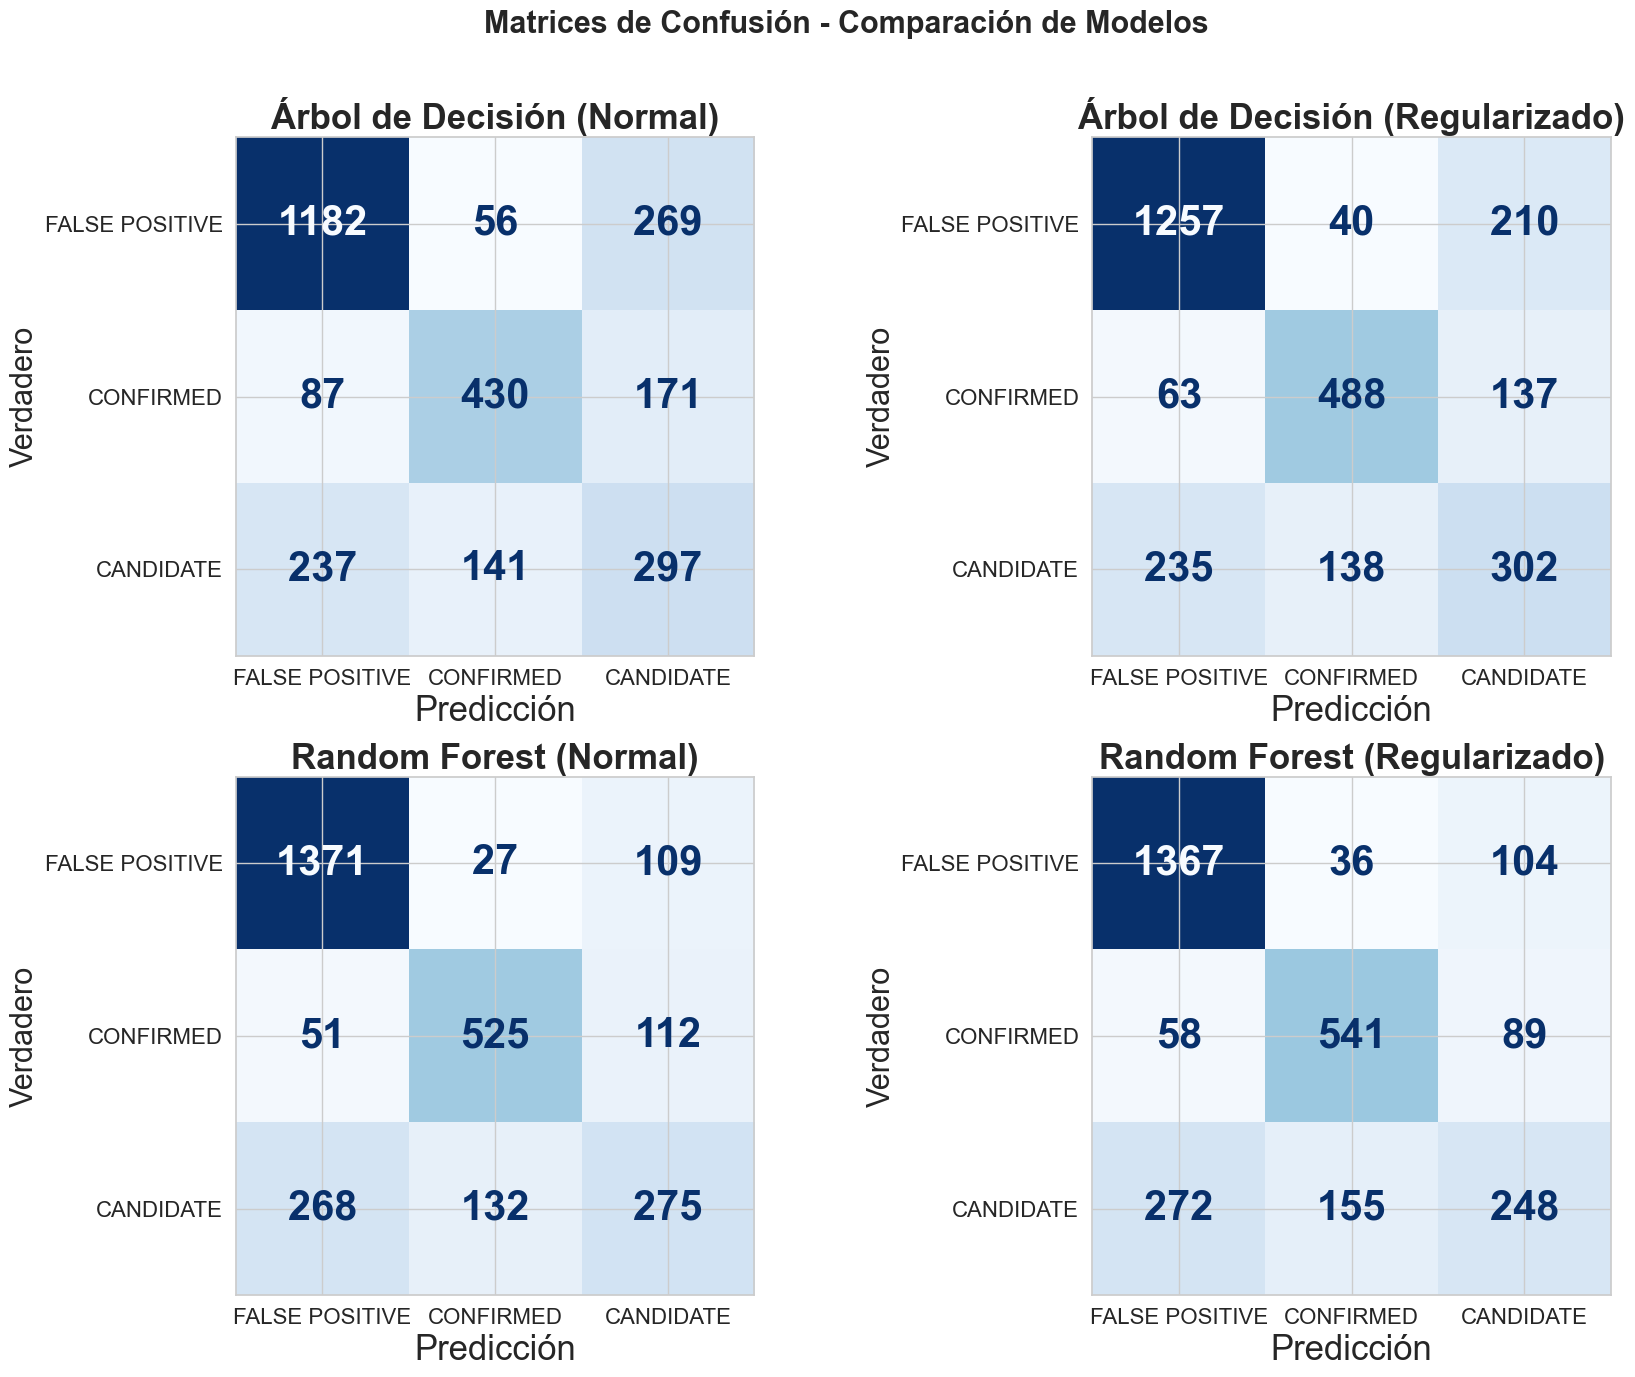

In [9]:
# =============================================================================
# 8. MATRICES DE CONFUSIÓN
# =============================================================================
print_section("MATRICES DE CONFUSIÓN")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))  # Tamaño general más grande
axes = axes.ravel()

for idx, (name, model_info) in enumerate(detailed_results.items()):
    y_pred = model_info['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)

    # Ajustes de texto
    axes[idx].set_title(f'{name}', fontsize=25, fontweight='bold')
    axes[idx].set_xlabel('Predicción', fontsize=25)
    axes[idx].set_ylabel('Verdadero', fontsize=22)
    axes[idx].tick_params(axis='both', labelsize=16)

    # Aumentar tamaño de los números dentro de las celdas
    for text in axes[idx].texts:
        text.set_fontsize(30)
        text.set_fontweight('bold')

plt.suptitle('Matrices de Confusión - Comparación de Modelos', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


CURVAS DE APRENDIZAJE - DIAGNÓSTICO

Curvas de aprendizaje para: Árbol de Decisión (Normal)


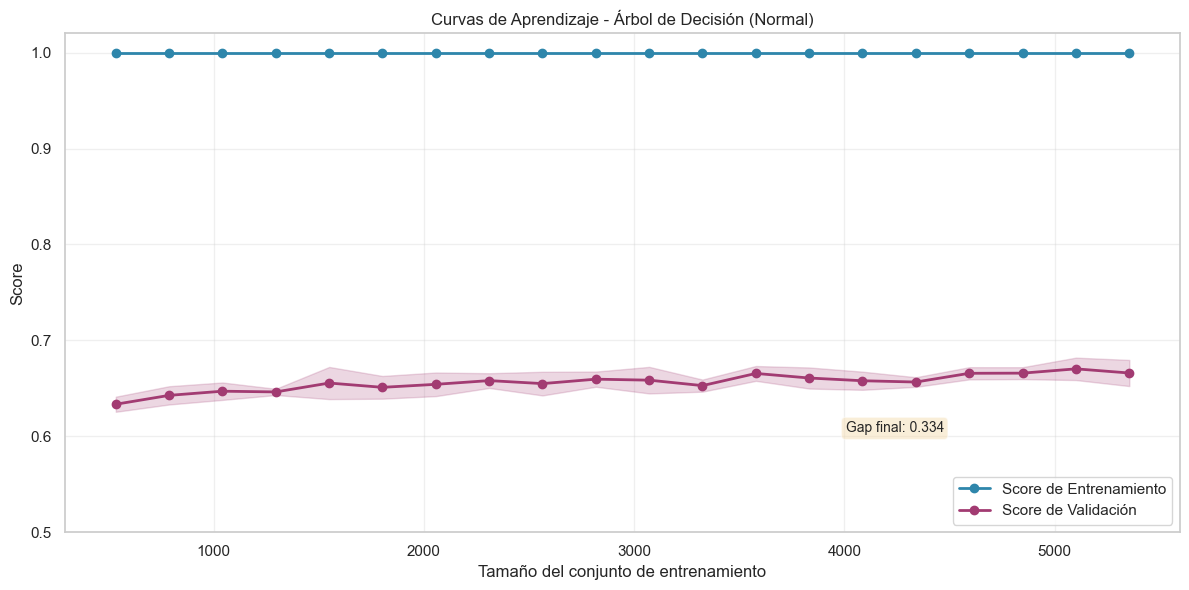

OVERFITTING detectado (gap = 0.334)

Curvas de aprendizaje para: Árbol de Decisión (Regularizado)


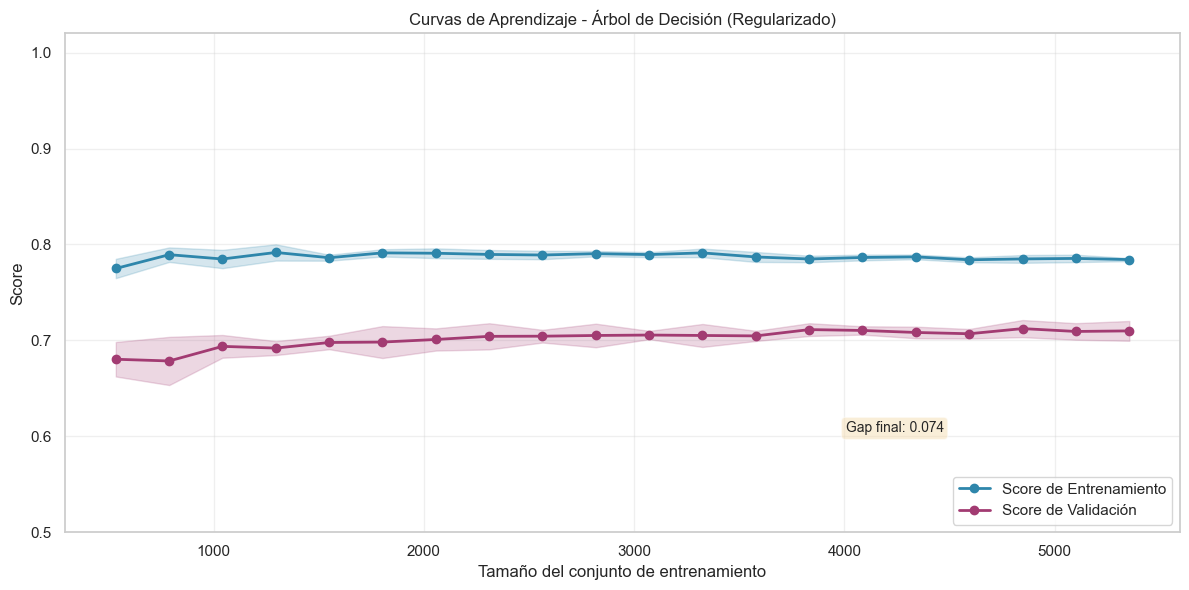

OVERFITTING detectado (gap = 0.074)

Curvas de aprendizaje para: Random Forest (Normal)


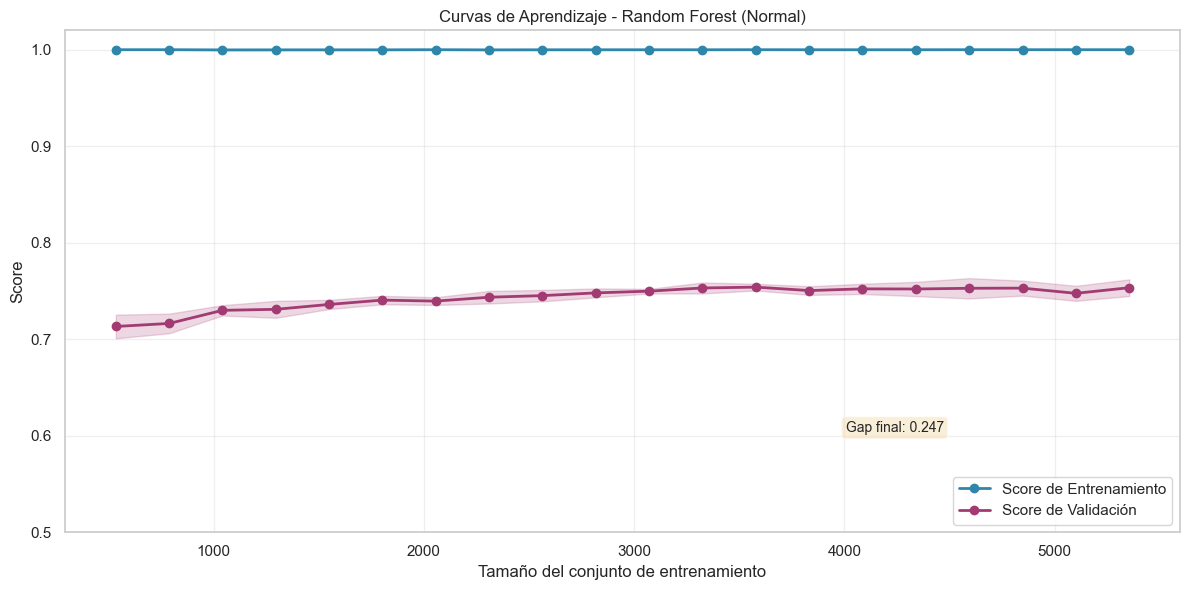

OVERFITTING detectado (gap = 0.247)

Curvas de aprendizaje para: Random Forest (Regularizado)


In [ ]:
# =============================================================================
# 9. CURVAS DE APRENDIZAJE
# =============================================================================
print_section("CURVAS DE APRENDIZAJE - DIAGNÓSTICO")

for name, model_info in detailed_results.items():
    print(f"\nCurvas de aprendizaje para: {name}")
    plot_learning_curves(model_info['model'], X_train_processed, y_train, 
                         title=f"Curvas de Aprendizaje - {name}")

In [ ]:
# =============================================================================
# 10. CONCLUSIONES Y RECOMENDACIONES
# =============================================================================
print_section("CONCLUSIONES Y RECOMENDACIONES")

# Encontrar el mejor modelo
best_model = results_df.loc[results_df['Test Accuracy'].idxmax()]
print(f"MEJOR MODELO: {best_model['Modelo']}")
print(f"  Accuracy: {best_model['Test Accuracy']:.4f}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")
print(f"  Overfitting Gap: {best_model['Overfitting Gap']:.4f}")

print(f"\nRESUMEN DE RENDIMIENTO:")
for _, row in results_df.iterrows():
    gap_status = "ALTO" if row['Overfitting Gap'] > 0.1 else "MODERADO" if row['Overfitting Gap'] > 0.05 else "BAJO"
    print(f"  {row['Modelo']}: Test={row['Test Accuracy']:.3f}, Gap={row['Overfitting Gap']:.3f} ({gap_status})")

print(f"\nRECOMENDACIONES:")
print("1. Los modelos regularizados muestran mejor generalización")
print("2. Random Forest generalmente supera a árboles individuales")
print("3. Considerar ensemble methods para mejorar rendimiento")
print("4. Validar en datos completamente nuevos")